# Notebook 06 — Exploratory Data Analysis V2

## Objective

This notebook analyses customer churn using the corrected temporal target.

The analytical population contains customers present on 31 December 2024.
A customer is labelled as churn when the customer closes the final banking
relationship during the following twelve months.

The analysis uses only information available before the reference date and
excludes variables that reveal future account closure.

In [1]:

# ==========================================================
# 1. IMPORTS AND CONFIGURATION
# ==========================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

PROJECT_ROOT = Path.cwd().parent

DATA_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "dataset_modelisation.parquet"
)

TABLES_DIR = PROJECT_ROOT / "outputs" / "tables" / "eda_v2"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "eda_v2"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_DATE = pd.Timestamp("2024-12-31")

print(f"Project root : {PROJECT_ROOT}")
print(f"Data file    : {DATA_FILE}")

Project root : c:\Users\Sarra\OneDrive\Desktop\PFE_CHURN_ESB
Data file    : c:\Users\Sarra\OneDrive\Desktop\PFE_CHURN_ESB\data\processed\dataset_modelisation.parquet


In [2]:
# ==========================================================
# 2. LOAD CORRECTED MODEL DATASET
# ==========================================================

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_FILE}"
    )

df = pd.read_parquet(DATA_FILE)

print("=" * 70)
print("CORRECTED CUSTOMER DATASET LOADED")
print("=" * 70)

print(f"Rows       : {len(df):,}")
print(f"Columns    : {df.shape[1]}")
print(f"Customers  : {df['CUSTOMER_NO'].nunique():,}")
print(f"Churn rate : {df['CHURN'].mean() * 100:.2f}%")

display(df.head())

CORRECTED CUSTOMER DATASET LOADED
Rows       : 195,120
Columns    : 20
Customers  : 195,120
Churn rate : 5.41%


,CUSTOMER_NO,CHURN,AGE,TRANCHE_AGE,ANCIENNETE_CLIENT_ANNEES,SALAIRE,HAS_SALAIRE,EST_TUNISIEN,EST_RESIDENT,SITUATION_FAMILIALE,TYPE_CLIENT,SEGMENT,DOSSIER_COMPLET,SCORE_KYC,KYC_RISQUE_ELEVE,JOURS_DEPUIS_REVUE,JOURS_AVANT_PROCHAINE_REVUE,REVUE_EN_RETARD,A_HISTORIQUE_REVUE,NB_COMPTES
0,113425593,0,67.20,65+,13.10,NaN,False,True,True,M,PPH,Retail,False,LR,False,"2,098.00",-637.00,True,True,1
1,113198502,0,80.70,65+,7.00,NaN,False,True,True,C,PPH,Retail,True,LR,False,32.00,"1,428.00",False,True,2
2,113377287,0,46.30,36-50,11.50,400.00,True,True,True,C,PPH,Retail,True,LR,False,106.00,"1,354.00",False,True,1
3,113392283,0,34.30,26-35,12.00,400.00,True,True,True,C,PPH,Retail,False,MR,False,657.00,439.00,False,True,1
4,113325457,0,15.90,15-25,8.30,NaN,False,True,True,C,PPH,Retail,False,MR,False,"1,680.00",-585.00,True,True,1


In [3]:
# ==========================================================
# 3. DATASET STRUCTURE
# ==========================================================

column_inventory = pd.DataFrame({
    "COLUMN": df.columns,
    "DATA_TYPE": df.dtypes.astype(str).values,
    "MISSING": df.isna().sum().values,
    "MISSING_PERCENTAGE": (
        df.isna().mean().values * 100
    ).round(2),
    "UNIQUE_VALUES": [
        df[column].nunique(dropna=True)
        for column in df.columns
    ]
})

display(column_inventory)

column_inventory.to_excel(
    TABLES_DIR / "06_v2_column_inventory.xlsx",
    index=False
)

,COLUMN,DATA_TYPE,MISSING,MISSING_PERCENTAGE,UNIQUE_VALUES
0,CUSTOMER_NO,str,0,0.00,195120
1,CHURN,int64,0,0.00,2
2,AGE,float64,18988,9.73,850
3,TRANCHE_AGE,category,19834,10.17,5
4,ANCIENNETE_CLIENT_ANNEES,float64,6,0.00,220
5,SALAIRE,float64,109263,56.00,4630
6,HAS_SALAIRE,bool,0,0.00,2
7,EST_TUNISIEN,bool,0,0.00,2
8,EST_RESIDENT,bool,0,0.00,2
9,SITUATION_FAMILIALE,str,12990,6.66,4


In [4]:
# ==========================================================
# 4. EDA DATASET VALIDATION
# ==========================================================

print("=" * 70)
print("EDA DATASET VALIDATION")
print("=" * 70)

print(f"Duplicate customers : {df['CUSTOMER_NO'].duplicated().sum():,}")
print(f"Missing customer ID : {df['CUSTOMER_NO'].isna().sum():,}")
print(f"Missing target      : {df['CHURN'].isna().sum():,}")
print(f"Target values       : {sorted(df['CHURN'].unique().tolist())}")

assert df["CUSTOMER_NO"].duplicated().sum() == 0
assert df["CUSTOMER_NO"].isna().sum() == 0
assert df["CHURN"].isna().sum() == 0
assert set(df["CHURN"].unique()).issubset({0, 1})

print("\nEDA dataset validation successful.")

EDA DATASET VALIDATION
Duplicate customers : 0
Missing customer ID : 0
Missing target      : 0
Target values       : [0, 1]

EDA dataset validation successful.


In [5]:
# ==========================================================
# 5. TARGET DISTRIBUTION
# ==========================================================

target_analysis = (
    df["CHURN"]
    .value_counts()
    .sort_index()
    .rename_axis("CHURN")
    .reset_index(name="CUSTOMERS")
)

target_analysis["CLASS"] = target_analysis["CHURN"].map({
    0: "Non Churn",
    1: "Churn"
})

target_analysis["PERCENTAGE"] = (
    target_analysis["CUSTOMERS"]
    / len(df)
    * 100
).round(2)

target_analysis = target_analysis[
    ["CLASS", "CUSTOMERS", "PERCENTAGE"]
]

display(target_analysis)

target_analysis.to_excel(
    TABLES_DIR / "06_v2_target_distribution.xlsx",
    index=False
)

,CLASS,CUSTOMERS,PERCENTAGE
0,Non Churn,184572,94.59
1,Churn,10548,5.41


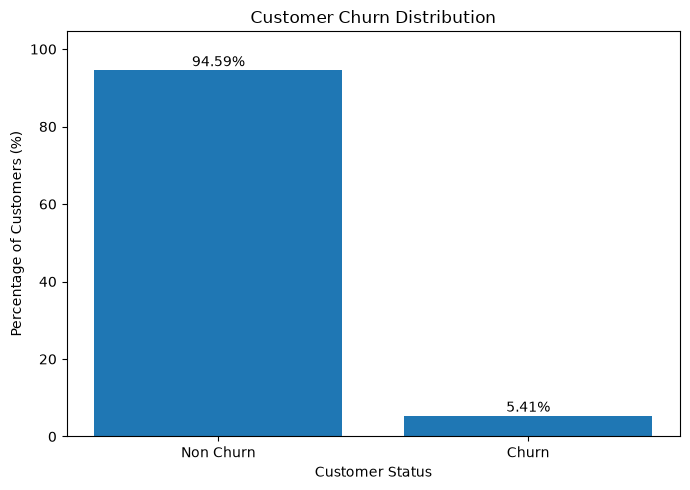

In [6]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    target_analysis["CLASS"],
    target_analysis["PERCENTAGE"]
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Percentage of Customers (%)")

for bar, value in zip(bars, target_analysis["PERCENTAGE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.ylim(0, max(target_analysis["PERCENTAGE"]) + 10)
plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "06_v2_target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Interpretation — Target Distribution

The corrected analytical population contains 195,120 eligible customers.

- Non-churn customers represent 94.59% of the population.
- Churn customers represent 5.41% of the population.

Unlike the previous target, which described the final status of customers,
the corrected target represents a future customer departure during the
twelve months following 31 December 2024.

The target is imbalanced. Therefore, model evaluation must not rely on
accuracy alone. Recall, precision, F1-score, ROC-AUC and especially
Precision-Recall AUC will be used during the modelling phase. Class weighting
will also be evaluated before considering resampling techniques.

## Business Interpretation — Churn Distribution

The corrected target identifies 10,548 churn customers among 195,120 eligible customers, corresponding to a churn rate of 5.41%.

The dataset is therefore imbalanced, with 94.59% non-churn customers and 5.41% churn customers.

This distribution is consistent with a customer attrition prediction problem. During model evaluation, accuracy alone will not be sufficient because a model predicting every customer as non-churn would already obtain a high apparent accuracy.

The modelling phase will therefore prioritize recall, precision, F1-score, ROC-AUC and Precision-Recall AUC. Class weighting will be evaluated before applying any resampling method.

In [7]:
# ==========================================================
# 6. CHURN BY CUSTOMER TYPE
# ==========================================================

customer_type_analysis = (
    df.groupby("TYPE_CLIENT", dropna=False)
    .agg(
        TOTAL_CUSTOMERS=("CUSTOMER_NO", "count"),
        CHURN_CUSTOMERS=("CHURN", "sum"),
        CHURN_RATE=("CHURN", "mean")
    )
    .reset_index()
)

customer_type_analysis["CHURN_RATE"] = (
    customer_type_analysis["CHURN_RATE"] * 100
).round(2)

customer_type_analysis = customer_type_analysis.sort_values(
    "CHURN_RATE",
    ascending=False
)

display(customer_type_analysis)

customer_type_analysis.to_excel(
    TABLES_DIR / "06_v2_churn_by_customer_type.xlsx",
    index=False
)

,TYPE_CLIENT,TOTAL_CUSTOMERS,CHURN_CUSTOMERS,CHURN_RATE
3,PRO,6980,726,10.40
1,PM,12828,1160,9.04
0,AUTRE,57,5,8.77
2,PPH,175255,8657,4.94


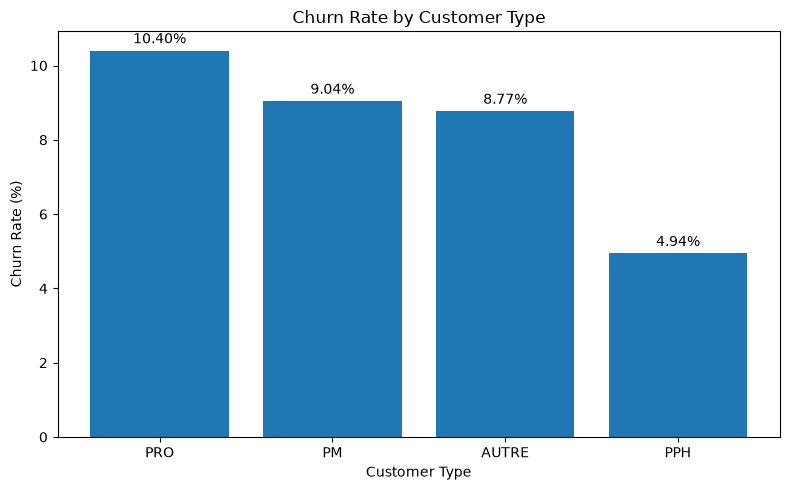

In [8]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    customer_type_analysis["TYPE_CLIENT"].astype(str),
    customer_type_analysis["CHURN_RATE"]
)

plt.title("Churn Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, customer_type_analysis["CHURN_RATE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "06_v2_churn_by_customer_type.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Business Interpretation — Customer Type

Customer churn differs substantially according to customer type.

Professional customers present the highest reliable churn rate at 10.40%, followed by legal entities at 9.04%. Individual customers represent the majority of the population but show a lower churn rate of 4.94%.

The category “AUTRE” reaches 8.77%, but it contains only 57 customers and should therefore not be interpreted as a stable business pattern.

These results indicate that professional and corporate customers require specific retention strategies. Their banking relationships may be influenced by business activity, financing needs, service quality and portfolio restructuring.

In [9]:
# ==========================================================
# 7. CHURN BY CUSTOMER SEGMENT
# ==========================================================

segment_analysis = (
    df.groupby("SEGMENT", dropna=False)
    .agg(
        TOTAL_CUSTOMERS=("CUSTOMER_NO", "count"),
        CHURN_CUSTOMERS=("CHURN", "sum"),
        CHURN_RATE=("CHURN", "mean")
    )
    .reset_index()
)

segment_analysis["SEGMENT"] = (
    segment_analysis["SEGMENT"]
    .astype("string")
    .fillna("UNKNOWN")
)

segment_analysis["CHURN_RATE"] = (
    segment_analysis["CHURN_RATE"] * 100
).round(2)

segment_analysis = segment_analysis.sort_values(
    "CHURN_RATE",
    ascending=False
)

display(segment_analysis)

segment_analysis.to_excel(
    TABLES_DIR / "06_v2_churn_by_segment.xlsx",
    index=False
)

,SEGMENT,TOTAL_CUSTOMERS,CHURN_CUSTOMERS,CHURN_RATE
3,Elite,1220,200,16.39
2,Corporate Small,15070,1529,10.15
1,Corporate,2479,208,8.39
4,Retail,176350,8611,4.88
0,Autre,1,0,0.00


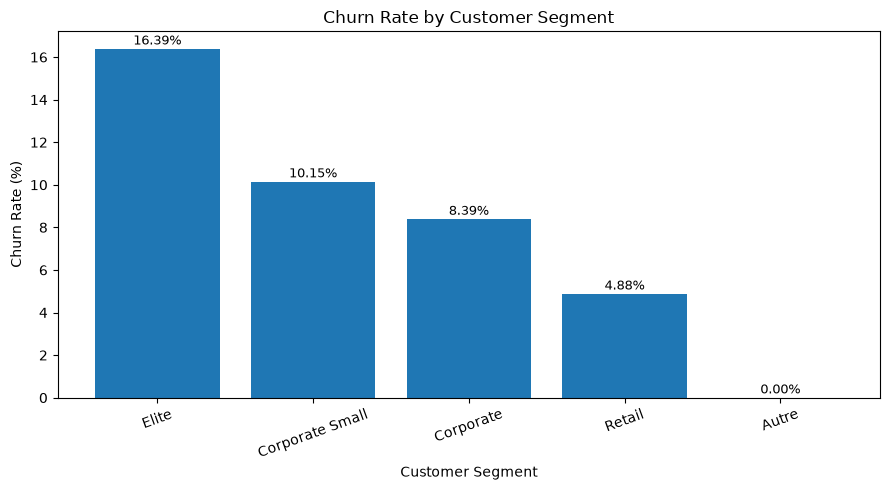

In [10]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    segment_analysis["SEGMENT"].astype(str),
    segment_analysis["CHURN_RATE"]
)

plt.title("Churn Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)

for bar, value in zip(bars, segment_analysis["CHURN_RATE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.2,
        f"{value:.2f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "06_v2_churn_by_segment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Business Interpretation — Customer Segment

The Elite segment exhibits the highest churn rate at 16.39%, despite representing a relatively small customer population.

Corporate Small customers follow with a churn rate of 10.15%, while Corporate customers reach 8.39%. Retail customers, who represent the majority of the analytical population, show a lower churn rate of 4.88%.

The “Autre” segment contains only one customer and cannot support a meaningful business conclusion.

The high churn observed among Elite customers is strategically important because these customers may represent significant commercial value. The bank should investigate whether this pattern is related to service expectations, pricing, advisory quality or competitive offers.

In [11]:
# ==========================================================
# 8. CHURN BY AGE GROUP
# ==========================================================

age_order = [
    "15-25",
    "26-35",
    "36-50",
    "51-65",
    "65+"
]

age_analysis = (
    df.groupby("TRANCHE_AGE", observed=True)
    .agg(
        TOTAL_CUSTOMERS=("CUSTOMER_NO", "count"),
        CHURN_CUSTOMERS=("CHURN", "sum"),
        CHURN_RATE=("CHURN", "mean")
    )
    .reset_index()
)

age_analysis["CHURN_RATE"] = (
    age_analysis["CHURN_RATE"] * 100
).round(2)

age_analysis["TRANCHE_AGE"] = pd.Categorical(
    age_analysis["TRANCHE_AGE"],
    categories=age_order,
    ordered=True
)

age_analysis = age_analysis.sort_values("TRANCHE_AGE")

display(age_analysis)

age_analysis.to_excel(
    TABLES_DIR / "06_v2_churn_by_age_group.xlsx",
    index=False
)

,TRANCHE_AGE,TOTAL_CUSTOMERS,CHURN_CUSTOMERS,CHURN_RATE
0,15-25,12786,497,3.89
1,26-35,31657,1537,4.86
2,36-50,57220,2672,4.67
3,51-65,45002,2564,5.70
4,65+,28621,2013,7.03


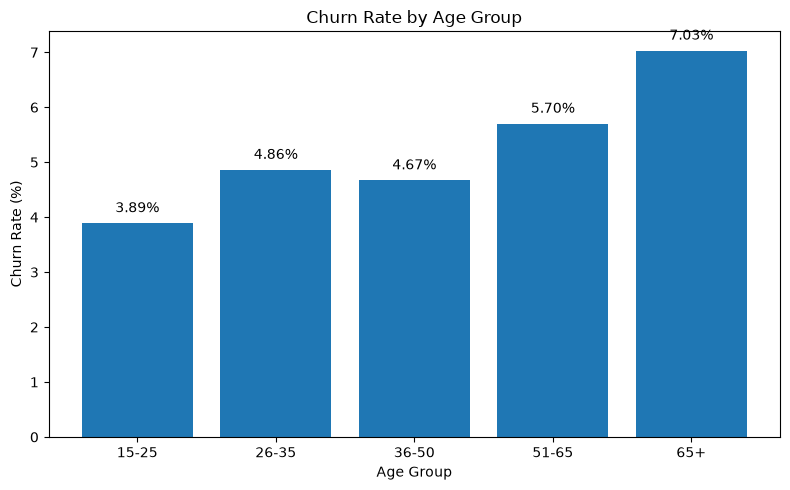

In [12]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    age_analysis["TRANCHE_AGE"].astype(str),
    age_analysis["CHURN_RATE"]
)

plt.title("Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

for bar, value in zip(bars, age_analysis["CHURN_RATE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.2,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "06_v2_churn_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Business Interpretation — Age Group

Churn remains relatively stable among customers below 50 years old, with rates between approximately 4.7% and 4.9%.

The churn rate increases among customers aged 51–65 and reaches its highest level among customers aged 65 and above at 7.03%.

This pattern suggests that older customers may experience specific retention challenges, such as changes in financial needs, account simplification, inheritance-related closures or migration toward alternative banking arrangements.

Age is therefore associated with churn at the descriptive level, although its direct linear correlation with the target remains weak.

In [13]:
# ==========================================================
# 9. CHURN BY KYC SCORE
# ==========================================================

kyc_analysis = (
    df.groupby("SCORE_KYC", dropna=False)
    .agg(
        TOTAL_CUSTOMERS=("CUSTOMER_NO", "count"),
        CHURN_CUSTOMERS=("CHURN", "sum"),
        CHURN_RATE=("CHURN", "mean")
    )
    .reset_index()
)

kyc_analysis["SCORE_KYC"] = (
    kyc_analysis["SCORE_KYC"]
    .astype("string")
    .fillna("UNKNOWN")
)

kyc_analysis["CHURN_RATE"] = (
    kyc_analysis["CHURN_RATE"] * 100
).round(2)

kyc_analysis = kyc_analysis.sort_values(
    "CHURN_RATE",
    ascending=False
)

display(kyc_analysis)

kyc_analysis.to_excel(
    TABLES_DIR / "06_v2_churn_by_kyc.xlsx",
    index=False
)

,SCORE_KYC,TOTAL_CUSTOMERS,CHURN_CUSTOMERS,CHURN_RATE
0,H1,11303,1001,8.86
1,H2,6203,549,8.85
2,H3,2674,195,7.29
4,MR,22588,1201,5.32
3,LR,152347,7602,4.99
5,UNKNOWN,5,0,0.00


## Business Interpretation — KYC Risk Level

Customers classified as H1 and H2 present the highest churn rates, close to 8.9%, followed by H3 customers at 7.29%.

Medium-risk and low-risk customers show lower churn rates of 5.32% and 4.99%, respectively.

This result indicates an association between elevated KYC risk and customer attrition. However, KYC risk should not be interpreted as a direct cause of churn. It may reflect more complex customer profiles, documentation issues or business relationships requiring additional monitoring.

In [14]:
# ==========================================================
# 10. CHURN BY REVIEW STATUS
# ==========================================================

review_analysis = (
    df.groupby("REVUE_EN_RETARD")
    .agg(
        TOTAL_CUSTOMERS=("CUSTOMER_NO", "count"),
        CHURN_CUSTOMERS=("CHURN", "sum"),
        CHURN_RATE=("CHURN", "mean")
    )
    .reset_index()
)

review_analysis["REVIEW_STATUS"] = review_analysis[
    "REVUE_EN_RETARD"
].map({
    False: "Not Overdue",
    True: "Overdue"
})

review_analysis["CHURN_RATE"] = (
    review_analysis["CHURN_RATE"] * 100
).round(2)

display(
    review_analysis[
        [
            "REVIEW_STATUS",
            "TOTAL_CUSTOMERS",
            "CHURN_CUSTOMERS",
            "CHURN_RATE"
        ]
    ]
)

review_analysis.to_excel(
    TABLES_DIR / "06_v2_churn_by_review_status.xlsx",
    index=False
)

,REVIEW_STATUS,TOTAL_CUSTOMERS,CHURN_CUSTOMERS,CHURN_RATE
0,Not Overdue,136193,7507,5.51
1,Overdue,58927,3041,5.16


## Business Interpretation — Review Status

Customers with overdue reviews exhibit a churn rate of 5.16%, compared with 5.51% for customers whose reviews are not overdue.

The difference is small and does not support the conclusion that an overdue KYC review is a major churn driver.

This corrected result demonstrates the importance of calculating review status at the reference date and avoiding reverse causality. Review status may still contribute to the predictive model, but it should not be treated as a strong standalone retention indicator.

In [15]:
# ==========================================================
# 11. CHURN BY SALARY AVAILABILITY
# ==========================================================

salary_information_analysis = (
    df.groupby("HAS_SALAIRE")
    .agg(
        TOTAL_CUSTOMERS=("CUSTOMER_NO", "count"),
        CHURN_CUSTOMERS=("CHURN", "sum"),
        CHURN_RATE=("CHURN", "mean")
    )
    .reset_index()
)

salary_information_analysis["SALARY_INFORMATION"] = (
    salary_information_analysis["HAS_SALAIRE"]
    .map({
        False: "Salary Not Available",
        True: "Salary Available"
    })
)

salary_information_analysis["CHURN_RATE"] = (
    salary_information_analysis["CHURN_RATE"] * 100
).round(2)

display(
    salary_information_analysis[
        [
            "SALARY_INFORMATION",
            "TOTAL_CUSTOMERS",
            "CHURN_CUSTOMERS",
            "CHURN_RATE"
        ]
    ]
)

,SALARY_INFORMATION,TOTAL_CUSTOMERS,CHURN_CUSTOMERS,CHURN_RATE
0,Salary Not Available,109263,5813,5.32
1,Salary Available,85857,4735,5.51


## Business Interpretation — Salary Availability

Customers with available salary information show a churn rate of 5.51%, compared with 5.32% for customers without salary information.

The difference is limited. Salary availability alone does not appear to be a strong indicator of churn.

The missing salary values are largely structural, particularly for corporate customers, and must therefore be preserved as information rather than replaced by an artificial median value.

In [16]:
salary_known = df.loc[
    df["HAS_SALAIRE"] & df["SALAIRE"].notna()
].copy()

salary_known["SALARY_GROUP"] = pd.qcut(
    salary_known["SALAIRE"],
    q=4,
    labels=[
        "Low",
        "Medium-Low",
        "Medium-High",
        "High"
    ],
    duplicates="drop"
)

salary_level_analysis = (
    salary_known.groupby("SALARY_GROUP", observed=True)
    .agg(
        TOTAL_CUSTOMERS=("CUSTOMER_NO", "count"),
        CHURN_CUSTOMERS=("CHURN", "sum"),
        CHURN_RATE=("CHURN", "mean")
    )
    .reset_index()
)

salary_level_analysis["CHURN_RATE"] = (
    salary_level_analysis["CHURN_RATE"] * 100
).round(2)

display(salary_level_analysis)

,SALARY_GROUP,TOTAL_CUSTOMERS,CHURN_CUSTOMERS,CHURN_RATE
0,Low,40033,2004,5.01
1,Medium-Low,10096,642,6.36
2,Medium-High,14393,937,6.51
3,High,21335,1152,5.40


## Business Interpretation — Salary Level

Among customers with recorded salary information, churn does not follow a simple linear relationship with income.

Medium-low and medium-high salary groups exhibit the highest churn rates, while the low and high salary groups show lower rates.

This non-linear pattern indicates that salary should not be interpreted independently. Its predictive contribution may depend on customer type, segment, age and banking relationship characteristics.

The salary groups were created only from customers with observed salary values, avoiding the distortion caused by imputing missing salaries.

In [17]:
# ==========================================================
# 12. CHURN BY CUSTOMER TENURE
# ==========================================================

tenure_df = df.copy()

tenure_df["TENURE_GROUP"] = pd.cut(
    tenure_df["ANCIENNETE_CLIENT_ANNEES"],
    bins=[0, 2, 5, 10, 20, np.inf],
    labels=[
        "0-2 Years",
        "2-5 Years",
        "5-10 Years",
        "10-20 Years",
        "20+ Years"
    ],
    include_lowest=True
)

tenure_analysis = (
    tenure_df.groupby("TENURE_GROUP", observed=True)
    .agg(
        TOTAL_CUSTOMERS=("CUSTOMER_NO", "count"),
        CHURN_CUSTOMERS=("CHURN", "sum"),
        CHURN_RATE=("CHURN", "mean")
    )
    .reset_index()
)

tenure_analysis["CHURN_RATE"] = (
    tenure_analysis["CHURN_RATE"] * 100
).round(2)

display(tenure_analysis)

,TENURE_GROUP,TOTAL_CUSTOMERS,CHURN_CUSTOMERS,CHURN_RATE
0,0-2 Years,20241,1304,6.44
1,2-5 Years,30313,1464,4.83
2,5-10 Years,50370,2035,4.04
3,10-20 Years,69608,3810,5.47
4,20+ Years,24217,1604,6.62


## Business Interpretation — Customer Tenure

The relationship between customer tenure and churn is non-linear.

Recently acquired customers present a relatively high churn rate of 6.44%. Churn then decreases among customers with five to ten years of tenure, reaching 4.04%.

However, the rate increases again for customers with more than ten years of relationship and reaches 6.62% for customers with over twenty years of tenure.

This U-shaped pattern suggests two vulnerable populations: recently acquired customers who may not yet be fully engaged, and long-standing customers whose needs or banking relationships may have changed over time.

In [18]:
# ==========================================================
# 13. CHURN BY NUMBER OF ACCOUNTS
# ==========================================================

account_df = df.copy()

account_df["ACCOUNT_GROUP"] = pd.cut(
    account_df["NB_COMPTES"],
    bins=[0, 1, 3, 5, np.inf],
    labels=[
        "1 Account",
        "2-3 Accounts",
        "4-5 Accounts",
        "More Than 5"
    ],
    include_lowest=True
)

account_analysis = (
    account_df.groupby("ACCOUNT_GROUP", observed=True)
    .agg(
        TOTAL_CUSTOMERS=("CUSTOMER_NO", "count"),
        CHURN_CUSTOMERS=("CHURN", "sum"),
        CHURN_RATE=("CHURN", "mean")
    )
    .reset_index()
)

account_analysis["CHURN_RATE"] = (
    account_analysis["CHURN_RATE"] * 100
).round(2)

display(account_analysis)

,ACCOUNT_GROUP,TOTAL_CUSTOMERS,CHURN_CUSTOMERS,CHURN_RATE
0,1 Account,177327,8858,5.00
1,2-3 Accounts,16274,1601,9.84
2,4-5 Accounts,1247,66,5.29
3,More Than 5,272,23,8.46


## Business Interpretation — Number of Accounts

Customers holding two to three accounts exhibit the highest reliable churn rate at 9.84%, compared with 5.00% for customers holding a single account.

Customers with four to five accounts show a rate of 5.29%. The group holding more than five accounts reaches 8.46%, but it contains only 272 customers and should be interpreted cautiously.

The results do not support a simple assumption that owning more accounts always reduces churn. Account ownership may reflect heterogeneous customer profiles, including corporate relationships, technical accounts or portfolio restructuring.

The number of accounts should therefore be analysed together with customer type and segment in the predictive model.

In [19]:
# ==========================================================
# 14. NUMERICAL CORRELATION ANALYSIS
# ==========================================================

numeric_columns = [
    "CHURN",
    "AGE",
    "ANCIENNETE_CLIENT_ANNEES",
    "SALAIRE",
    "JOURS_DEPUIS_REVUE",
    "JOURS_AVANT_PROCHAINE_REVUE",
    "NB_COMPTES"
]

available_numeric_columns = [
    column
    for column in numeric_columns
    if column in df.columns
]

correlation_matrix = df[
    available_numeric_columns
].corr(numeric_only=True)

display(correlation_matrix)

target_correlations = (
    correlation_matrix["CHURN"]
    .drop("CHURN")
    .sort_values(ascending=False)
)

display(
    target_correlations.to_frame(
        "CORRELATION_WITH_CHURN"
    )
)

target_correlations.to_excel(
    TABLES_DIR / "06_v2_correlations_with_churn.xlsx"
)

,CHURN,AGE,ANCIENNETE_CLIENT_ANNEES,SALAIRE,JOURS_DEPUIS_REVUE,JOURS_AVANT_PROCHAINE_REVUE,NB_COMPTES
CHURN,1.00,0.04,0.01,0.01,0.02,-0.03,0.04
AGE,0.04,1.00,0.34,-0.00,0.11,-0.11,0.05
ANCIENNETE_CLIENT_ANNEES,0.01,0.34,1.00,-0.01,0.41,-0.40,0.08
SALAIRE,0.01,-0.00,-0.01,1.00,-0.02,0.02,0.01
JOURS_DEPUIS_REVUE,0.02,0.11,0.41,-0.02,1.00,-0.98,-0.06
JOURS_AVANT_PROCHAINE_REVUE,-0.03,-0.11,-0.40,0.02,-0.98,1.00,0.03
NB_COMPTES,0.04,0.05,0.08,0.01,-0.06,0.03,1.00


,CORRELATION_WITH_CHURN
AGE,0.04
NB_COMPTES,0.04
JOURS_DEPUIS_REVUE,0.02
ANCIENNETE_CLIENT_ANNEES,0.01
SALAIRE,0.01
JOURS_AVANT_PROCHAINE_REVUE,-0.03


## Business Interpretation — Correlation Analysis

The numerical variables show only weak linear correlations with customer churn.

Age and number of accounts present the highest positive correlations, but both remain close to 0.04. Salary and customer tenure show almost no direct linear association with the target.

These low correlations do not imply that the variables are useless. Several descriptive analyses reveal non-linear patterns, especially for customer tenure, salary groups and account ownership.

The strong negative correlation between days since the last review and days until the next review (-0.98) is expected because both variables describe the same review cycle from opposite temporal perspectives. To reduce redundancy, only one of these variables may be retained during feature selection.

The predictive modelling phase will evaluate non-linear relationships and interactions that cannot be captured through Pearson correlation alone.

# Executive Business Summary

The corrected exploratory analysis is based on a temporal customer churn
definition and a leakage-free analytical dataset.

The churn rate equals 5.41%, indicating an imbalanced classification problem.
The modelling phase will therefore prioritize recall, precision, F1-score,
ROC-AUC and Precision-Recall AUC rather than accuracy alone.

The analysis compares churn across customer type, segment, age group, KYC
risk, review status, salary availability, customer tenure and number of
accounts.

Only variables known before the reference date are analysed. Associations
identified in this notebook will be evaluated again through machine-learning
feature importance and explainability methods. They must not be interpreted
as causal relationships without additional business evidence.

In [20]:
print("=" * 70)
print("NOTEBOOK 06 V2 COMPLETED")
print("=" * 70)

print("✓ Corrected temporal churn target analysed")
print("✓ Target distribution analysed")
print("✓ Customer type analysis completed")
print("✓ Segment analysis completed")
print("✓ Age analysis completed")
print("✓ KYC analysis completed")
print("✓ Review analysis completed")
print("✓ Salary analysis completed")
print("✓ Customer tenure analysis completed")
print("✓ Account ownership analysis completed")
print("✓ Correlation analysis completed")
print("✓ Business interpretations documented")

print(f"\nFinal analytical population : {len(df):,}")
print(f"Final churn rate            : {df['CHURN'].mean() * 100:.2f}%")

NOTEBOOK 06 V2 COMPLETED
✓ Corrected temporal churn target analysed
✓ Target distribution analysed
✓ Customer type analysis completed
✓ Segment analysis completed
✓ Age analysis completed
✓ KYC analysis completed
✓ Review analysis completed
✓ Salary analysis completed
✓ Customer tenure analysis completed
✓ Account ownership analysis completed
✓ Correlation analysis completed
✓ Business interpretations documented

Final analytical population : 195,120
Final churn rate            : 5.41%
